In [156]:
#importing libraries 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

pd.options.display.max_rows=999
pd.options.display.max_columns=500

In [157]:
df=pd.read_csv('nba.csv')
df.head(10)

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0.0,PG,25.0,6-2,180.0,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99.0,SF,25.0,6-6,235.0,Marquette,6796117.0
2,John Holland,Boston Celtics,30.0,SG,27.0,6-5,205.0,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28.0,SG,22.0,6-5,185.0,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8.0,PF,29.0,6-10,231.0,NaN,5000000.0
5,Amir Johnson,Boston Celtics,90.0,PF,29.0,6-9,240.0,NaN,12000000.0
6,Jordan Mickey,Boston Celtics,55.0,PF,21.0,6-8,235.0,LSU,1170960.0
7,Kelly Olynyk,Boston Celtics,41.0,C,25.0,7-0,238.0,Gonzaga,2165160.0
8,Terry Rozier,Boston Celtics,12.0,PG,22.0,6-2,190.0,Louisville,1824360.0
9,Marcus Smart,Boston Celtics,36.0,PG,22.0,6-4,220.0,Oklahoma State,3431040.0


In [158]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      457 non-null    object 
 1   Team      457 non-null    object 
 2   Number    457 non-null    float64
 3   Position  457 non-null    object 
 4   Age       457 non-null    float64
 5   Height    457 non-null    object 
 6   Weight    457 non-null    float64
 7   College   373 non-null    object 
 8   Salary    446 non-null    float64
dtypes: float64(4), object(5)
memory usage: 32.3+ KB


In [159]:
df.describe()

,Number,Age,Weight,Salary
count,457.000000,457.000000,457.000000,4.460000e+02
mean,17.678337,26.938731,221.522976,4.842684e+06
std,15.966090,4.404016,26.368343,5.229238e+06
min,0.000000,19.000000,161.000000,3.088800e+04
25%,5.000000,24.000000,200.000000,1.044792e+06
50%,13.000000,26.000000,220.000000,2.839073e+06
75%,25.000000,30.000000,240.000000,6.500000e+06
max,99.000000,40.000000,307.000000,2.500000e+07


           count          mean     median       min         max           std
age_group                                                                    
19-24        150  2.706212e+06  1654380.0   30888.0  16407501.0  3.188468e+06
25-29        177  5.698207e+06  3533333.0   55722.0  20158622.0  5.547491e+06
30-34         89  7.084467e+06  5219169.0  200600.0  22970500.0  6.142556e+06
35-40         30  3.826837e+06  2854940.0  222888.0  25000000.0  4.640823e+06


Text(0, 0.5, 'Age')

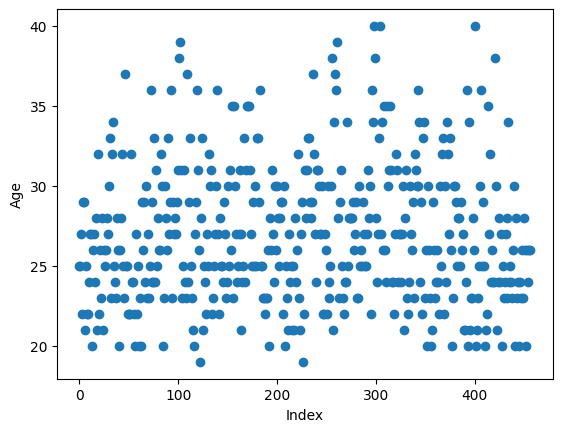

In [160]:
# Five edges create four bins: [19-25), [25-30), [30-35), [35-41)
df['age_group'] = pd.cut(df['Age'], 
                         bins=[19, 25, 30, 35, 41], 
                         labels=['19-24', '25-29', '30-34', '35-40'], 
                         right=False)
# print(df)
# Now apply groupby
result = df.groupby('age_group', observed=True)['Salary'].agg(['count','mean', 'median', 'min', 'max', 'std'])
# result = df.groupby('age_group', observed=True)['Salary'].describe()
print(result)


plt.scatter(df.index,df['Age'])
plt.xlabel('Index')
plt.ylabel('Age')

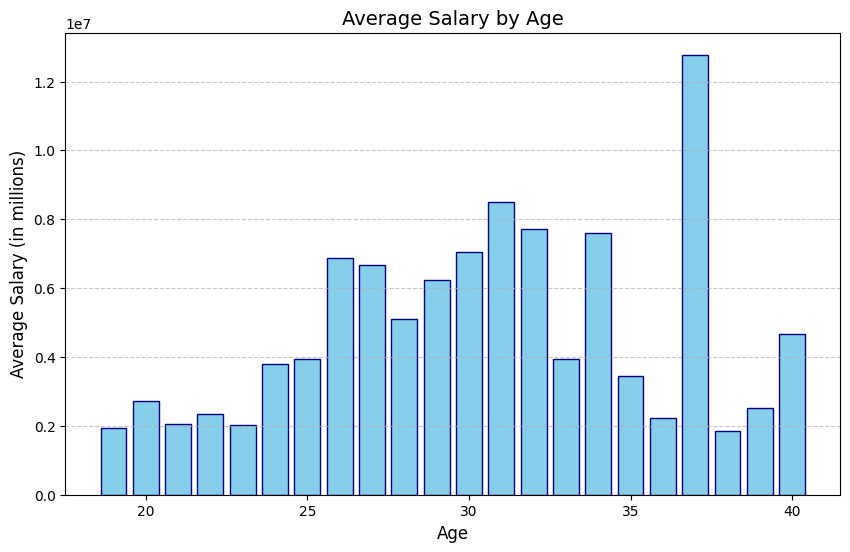

In [161]:
df_clean = df.dropna(subset=['Age', 'Salary'])

#  Group by Age and calculate the mean Salary
age_salary = df_clean.groupby('Age')['Salary'].mean()

# print(age_salary)

#  Create the bar graph
plt.figure(figsize=(10, 6))
plt.bar(age_salary.index, age_salary.values, color='skyblue', edgecolor='navy')

#  Add labels and formatting
plt.title('Average Salary by Age', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Average Salary (in millions)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

In [162]:
df=pd.read_csv('IRIS.csv')
print(df)

     sepal_length  sepal_width  petal_length  petal_width          species
0             5.1          3.5           1.4          0.2      Iris-setosa
1             4.9          3.0           1.4          0.2      Iris-setosa
2             4.7          3.2           1.3          0.2      Iris-setosa
3             4.6          3.1           1.5          0.2      Iris-setosa
4             5.0          3.6           1.4          0.2      Iris-setosa
5             5.4          3.9           1.7          0.4      Iris-setosa
6             4.6          3.4           1.4          0.3      Iris-setosa
7             5.0          3.4           1.5          0.2      Iris-setosa
8             4.4          2.9           1.4          0.2      Iris-setosa
9             4.9          3.1           1.5          0.1      Iris-setosa
10            5.4          3.7           1.5          0.2      Iris-setosa
11            4.8          3.4           1.6          0.2      Iris-setosa
12            4.8        

In [163]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [164]:
# Clean column names to remove leading/trailing spaces if necessary
df.columns = df.columns.str.strip()

In [165]:
# using group by or looping to separate the stats for each species 
species=df.groupby('species', observed=True).describe()
print(species)

# OR 

species_list = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
# print(df)
for species in species_list:
    print(f"\n\t--- Statistical Details for {species} ---\n")
    print(df[df['species'] == species].describe())

                sepal_length                                              \
                       count   mean       std  min    25%  50%  75%  max   
species                                                                    
Iris-setosa             50.0  5.006  0.352490  4.3  4.800  5.0  5.2  5.8   
Iris-versicolor         50.0  5.936  0.516171  4.9  5.600  5.9  6.3  7.0   
Iris-virginica          50.0  6.588  0.635880  4.9  6.225  6.5  6.9  7.9   

                sepal_width                                                \
                      count   mean       std  min    25%  50%    75%  max   
species                                                                     
Iris-setosa            50.0  3.418  0.381024  2.3  3.125  3.4  3.675  4.4   
Iris-versicolor        50.0  2.770  0.313798  2.0  2.525  2.8  3.000  3.4   
Iris-virginica         50.0  2.974  0.322497  2.2  2.800  3.0  3.175  3.8   

                petal_length                                               \
   

In [166]:
# Displaying the 90th percentile for each species
print(df.groupby('species', observed=True).quantile(0.25))

                 sepal_length  sepal_width  petal_length  petal_width
species                                                              
Iris-setosa             4.800        3.125           1.4          0.2
Iris-versicolor         5.600        2.525           4.0          1.2
Iris-virginica          6.225        2.800           5.1          1.8
